# Compare Explanation Families

This notebook keeps the Stage 2 comparison explicit and small. It compares the best non-anonymized concept, rationale, and attribution configurations against their matching no-explanation baselines.

What this notebook does:

1. Load one judge's v2 score CSV.
2. Select non-anonymized concept/rationale/attribution rows.
3. Pick the best method/configuration per family by mean score.
4. Plot pairwise comparisons, baseline differences, and score violins.
5. Print the current best-method allow-list for Stage 3.

## 0. Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.plot import (
    plot_accuracies_violins,
    plot_difference_bars,
    plot_pairwise_comparison_matrices,
)
from utils.analysis import filter_keep, preprocess, print_df_keys, score_diff

DATA_DIR = REPO_ROOT / "data"
EXPORT_DIR = REPO_ROOT / "LaTeX-Simulatability-Shortcut" / "plots"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = "Qwen_Qwen3.5-9B"
CSV_PATH = DATA_DIR / f"consim_{MODEL_FILE}_v2.csv"
assert CSV_PATH.exists(), f"No score CSV found at {CSV_PATH}"

df = pd.read_csv(CSV_PATH)
df = preprocess(df, seeds_per_bucket=5)

print_df_keys(df)

DataFrame has 22,943 rows.
dataset: ['AG', 'BIOS', 'E', 'GE', 'IMDB', 'RT']
model: ['DB', 'RB', 'B']
classes_subset: ['[0, 1, 2, 3]', '[1, 21, 24]', '[21, 22, 26]', '[6, 19, 25]', '[9, 11, 18]', '[0, 1, 2, 3, 4, 5]', '[2, 3, 27]', '[0, 1]']
group_seed: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
method: ['ClassesAs', 'ICA', 'NeuronsAs', 'PCA', 'Qwen/Qwen3.5-2B', 'SVD', 'SemiNMF', 'VanillaSAE', 'baseline', 'gradient_shap', 'integrated_gradients', 'kernel_shap', 'lime', 'meta-llama/Llama-3.2-3B-Instruct', 'occlusion', 'saliency', 'smooth_grad', 'sobol', 'square_grad', 'var_grad']
interpretation: [nan, 'llm', 'topk']
prompt_type: ['AC1', 'AC2', 'AC3', 'C1', 'C2', 'C3', 'AR1', 'R1', 'AB1', 'AB2', 'B1', 'B2', 'A1', 'AA1']
specification: ['new_consim', 'old_consim', 'simulator_consim', 'rationales', 'attributions']


## 1. Keep Non-Anonymized Family Rows

Concepts use `new_consim` and `topk`; `ClassesAs` is excluded because it is a control, not an explanation method. Rationales use `R1`; attributions use `A1`.

In [2]:
concepts = filter_keep(
    df,
    keep={
        "specification": ["new_consim"],
        "interpretation": ["topk"],
        "prompt_type": ["C1", "C2", "C3"],
    },
    filters={"method": ["ClassesAs"]},
)
rationales = filter_keep(
    df,
    keep={"specification": ["rationales"], "prompt_type": ["R1"]},
)
attributions = filter_keep(
    df,
    keep={"specification": ["attributions"], "prompt_type": ["A1"]},
    filters={"method": ["kernel_shap"]}
)

print("Concept rows:", len(concepts))
print("Rationale rows:", len(rationales))
print("Attribution rows:", len(attributions))

Concept rows: 1620
Rationale rows: 180
Attribution rows: 810


## 2. Select Best Configurations

In [3]:
def best_config(scores):
    table = scores.reset_index(name="score")
    if "interpretation" not in table.columns:
        table["interpretation"] = "None"
    table["interpretation"] = table["interpretation"].fillna("None")
    means = table.groupby(["method", "interpretation", "prompt_type"], dropna=False)["score"].mean()
    method, interpretation, prompt_type = means.sort_values(ascending=False).index[0]
    return method, interpretation, prompt_type, means.loc[(method, interpretation, prompt_type)]

concept_method, concept_interpretation, concept_prompt, concept_score = best_config(concepts)
rationale_method, rationale_interpretation, rationale_prompt, rationale_score = best_config(rationales)
attribution_method, attribution_interpretation, attribution_prompt, attribution_score = best_config(attributions)

best_configs = pd.DataFrame([
    {"family": "concepts", "method": concept_method, "interpretation": concept_interpretation, "prompt_type": concept_prompt, "mean_score": concept_score},
    {"family": "rationales", "method": rationale_method, "interpretation": rationale_interpretation, "prompt_type": rationale_prompt, "mean_score": rationale_score},
    {"family": "attributions", "method": attribution_method, "interpretation": attribution_interpretation, "prompt_type": attribution_prompt, "mean_score": attribution_score},
])
best_configs

,family,method,interpretation,prompt_type,mean_score
0,concepts,VanillaSAE,topk,C2,0.674778
1,rationales,Qwen/Qwen3.5-2B,None,R1,0.651444
2,attributions,lime,None,A1,0.666889


## 3. Pairwise Comparison of Best Configurations

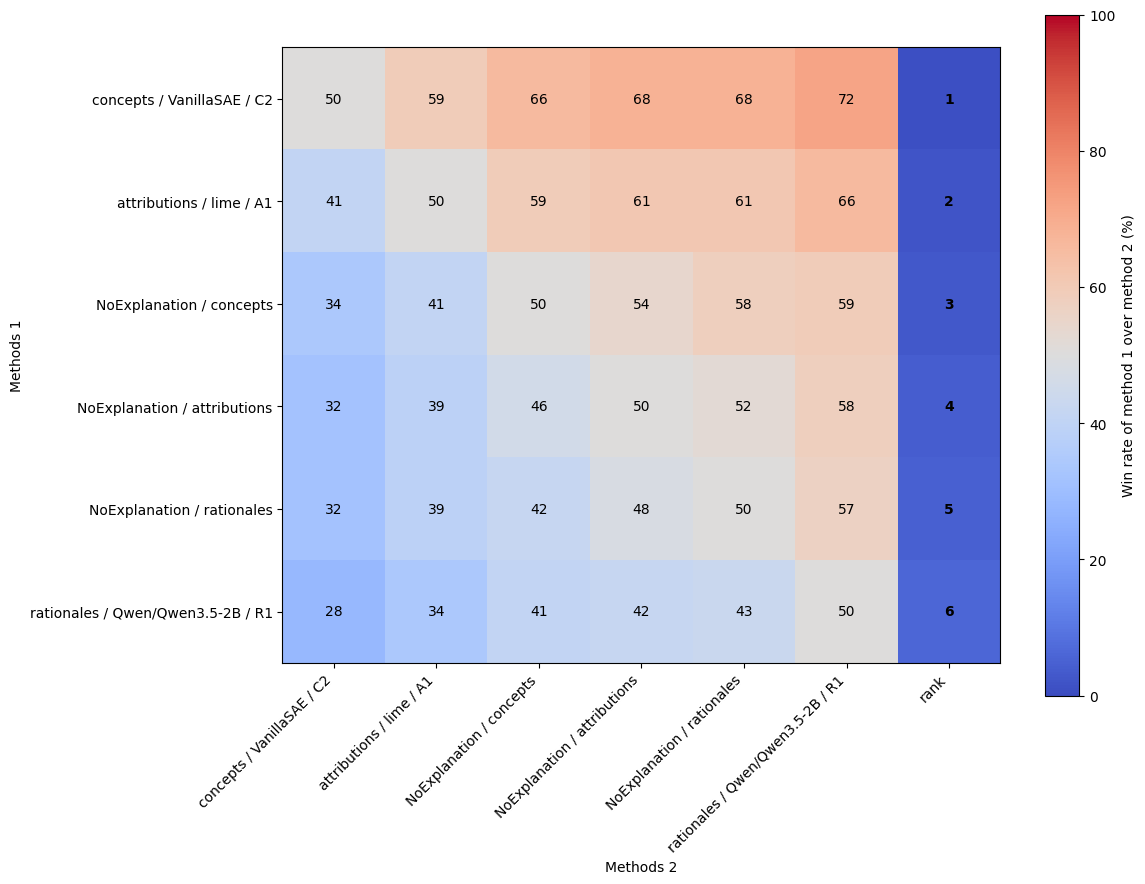

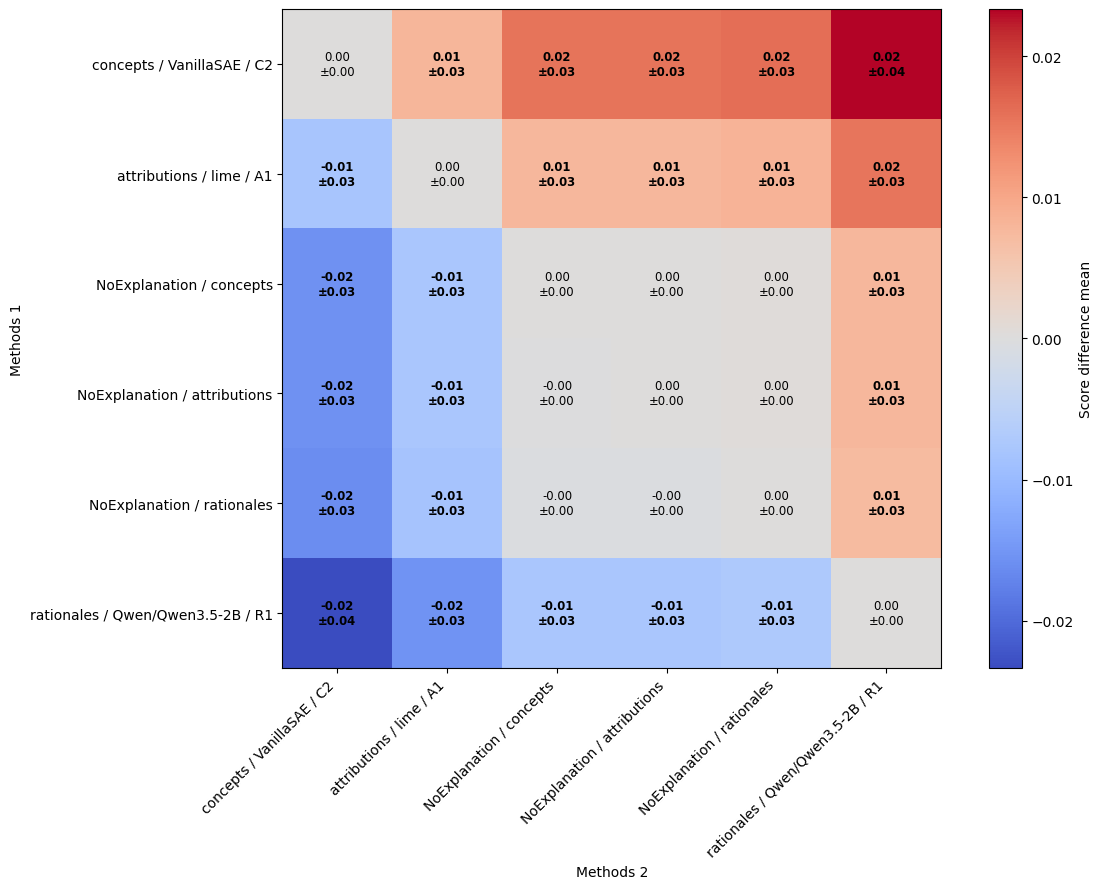

In [4]:
def keep_method_prompt(scores, method, prompt_type):
    return filter_keep(scores, keep={"method": [method], "prompt_type": [prompt_type]}, drop_single_level=True)

def contender(scores, label):
    table = scores.reset_index(name="score")
    table["contender"] = label
    return table.set_index(["dataset", "model", "classes_subset", "group_seed", "contender"])["score"]

def baseline(specification, prompt_type):
    baseline_prompt = {"C1": "B1", "C2": "B2", "C3": "B2", "R1": "B2", "A1": "B2"}[prompt_type]
    return filter_keep(
        df,
        keep={"specification": [specification], "method": ["baseline"], "prompt_type": [baseline_prompt]},
        drop_single_level=True,
    )

best_concepts = keep_method_prompt(concepts, concept_method, concept_prompt)
best_rationales = keep_method_prompt(rationales, rationale_method, rationale_prompt)
best_attributions = keep_method_prompt(attributions, attribution_method, attribution_prompt)

family_scores = pd.concat([
    contender(best_concepts, f"concepts / {concept_method} / {concept_prompt}"),
    contender(best_rationales, f"rationales / {rationale_method} / {rationale_prompt}"),
    contender(best_attributions, f"attributions / {attribution_method} / {attribution_prompt}"),
    contender(baseline("new_consim", concept_prompt), "NoExplanation / concepts"),
    contender(baseline("rationales", rationale_prompt), "NoExplanation / rationales"),
    contender(baseline("attributions", attribution_prompt), "NoExplanation / attributions"),
])

fig_pct, fig_diff, percentage_matrix, difference_matrix = plot_pairwise_comparison_matrices(
    family_scores,
    compared_index="contender",
    figsize=(12, 9),
)
fig_pct.savefig(EXPORT_DIR / "families_best_pairwise_winrate.pdf")
fig_diff.savefig(EXPORT_DIR / "families_best_pairwise_difference.pdf")
plt.show()

## 4. Difference to Matching Baseline

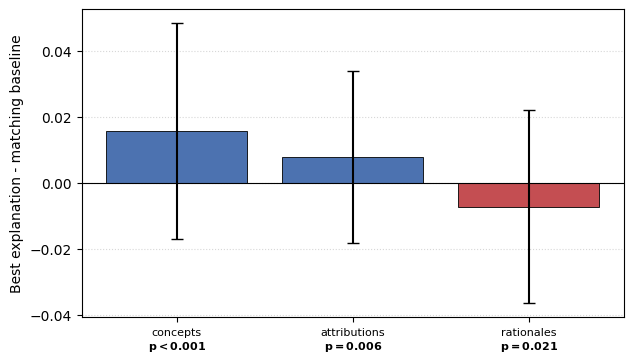

In [5]:
def paired_scores(scores):
    table = scores.reset_index(name="score")
    return table.set_index(["dataset", "model", "classes_subset", "group_seed"])["score"]

def difference_to_baseline(scores, baseline_scores, label):
    diff = score_diff(paired_scores(baseline_scores), paired_scores(scores))
    table = diff.reset_index(name="score")
    table["contender"] = label
    return table.set_index(["dataset", "model", "classes_subset", "group_seed", "contender"])["score"]

differences = pd.concat([
    difference_to_baseline(best_concepts, baseline("new_consim", concept_prompt), "concepts"),
    difference_to_baseline(best_rationales, baseline("rationales", rationale_prompt), "rationales"),
    difference_to_baseline(best_attributions, baseline("attributions", attribution_prompt), "attributions"),
])

fig, _ = plot_difference_bars(
    differences,
    comparison_col="contender",
    ylabel="Best explanation - matching baseline",
)
fig.savefig(EXPORT_DIR / "families_best_baseline_diff.pdf")
plt.show()

## 5. Violin Plot

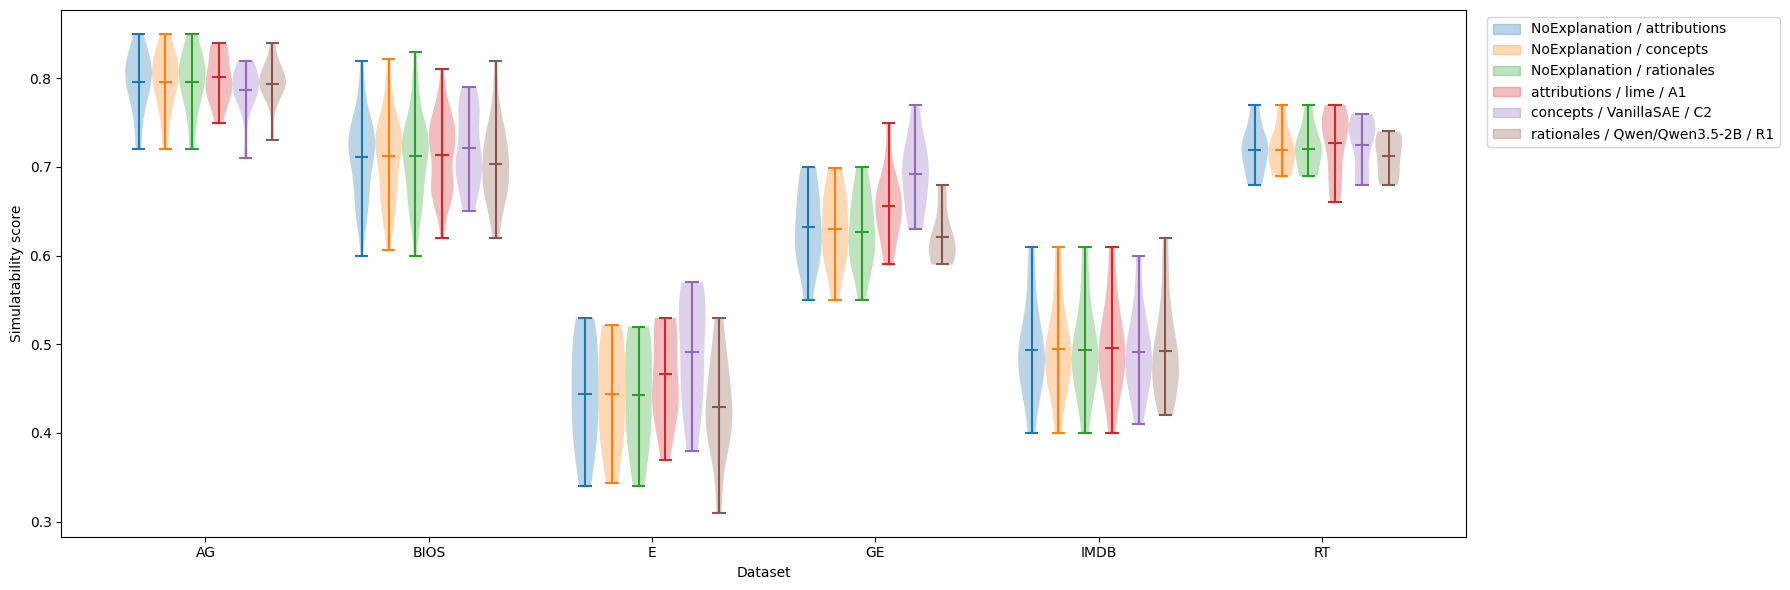

In [6]:
fig, _ = plot_accuracies_violins(
    family_scores,
    group_col="dataset",
    atom_col="contender",
    ylabel="Simulatability score",
)
fig.savefig(EXPORT_DIR / "families_best_violins.pdf")
plt.show()

## 6. Stage 3 Allow-List

In [7]:
allow_list = {
    "concepts": [{"method": concept_method, "interpretation": concept_interpretation, "prompt_type": concept_prompt}],
    "rationales": [{"method": rationale_method, "prompt_type": rationale_prompt}],
    "attributions": [{"method": attribution_method, "prompt_type": attribution_prompt}],
    "baselines": ["B1", "B2"],
    "source_score_file": str(CSV_PATH.relative_to(REPO_ROOT)),
}
allow_list

{'concepts': [{'method': 'VanillaSAE',
   'interpretation': 'topk',
   'prompt_type': 'C2'}],
 'rationales': [{'method': 'Qwen/Qwen3.5-2B', 'prompt_type': 'R1'}],
 'attributions': [{'method': 'lime', 'prompt_type': 'A1'}],
 'baselines': ['B1', 'B2'],
 'source_score_file': 'data/consim_Qwen_Qwen3.5-9B_v2.csv'}